In [1]:
from pathlib import Path
from typing import Dict, Tuple, Iterable, Optional, List
import json
import math
import numpy as np
from matplotlib import pyplot as plt
from scipy.stats import norm
# RUNS_DIR = Path('/DATA/scastedo/runs_may_15_dynamical_1')
# RUNS_DIR = Path('/DATA/scastedo/runs_may_8_1')
# RUNS_DIR = Path('/DATA/scastedo/runs_may_18_dynamical_5')
RUNS_DIR = Path('/DATA/scastedo/runs_may_19_dynamical_1')


def build_state_tensors(
    runs_dir: Path = RUNS_DIR,
    ampar_values: Optional[Iterable[float]] = None,
    rin_values: Optional[Iterable[float]] = None,
    eta_values: Optional[Iterable[float]] = None,
    temp_values: Optional[Iterable[float]] = None,
    sigma_theta_values: Optional[Iterable[float]] = None,
    idir_values: Optional[Iterable[float]] = None,
    trials: Optional[Iterable[int]] = None,
    threshold_active_fraction_values: Optional[Iterable[float]] = None,
    active_fraction_values: Optional[Iterable[float]] = None,
    recurrent_width_values: Optional[Iterable[float]] = None,
    I_str_values: Optional[Iterable[float]] = None,
    I_sigma_values: Optional[Iterable[float]] = None,
    strict: bool = True,
    tol: float = 1e-12,
) -> Tuple[
    Dict[Tuple[float, float, float, float, float, float, float], np.ndarray],
    List[float],
    List[float],
    List[float],
    List[float],
    List[float],
    List[float],
    List[int],
    int,
    List[float],
    List[float],
    List[float],
    List[float],
]:
    """Load run metadata and state histories into tensors.

    Returns tensors keyed by
      (ampar, rin, sigma_temp, sigma_eta, sigma_theta, recurrent_width, active_fraction)
    plus parameter axes and network parameter values from metadata.

    Backward compatibility:
      - If new metadata fields are missing, falls back to older fields.
      - threshold_active_fraction_values remains as an alias for active_fraction_values.
    """
    def sorted_unique(values: Iterable[float]) -> List[float]:
        return sorted({v for v in values if v is not None})

    def in_allowed(value, allowed: Optional[Iterable[float]]) -> bool:
        if allowed is None:
            return True
        if value is None:
            return False
        if isinstance(value, (float, int)):
            return any(math.isclose(float(value), float(v), rel_tol=tol, abs_tol=tol) for v in allowed)
        return value in allowed

    def load_state_matrix(folder: Path) -> np.ndarray:
        history_file = folder / "state_history.npy"
        if not history_file.exists():
            raise FileNotFoundError(f"Missing state history file: {history_file}")
        states = np.load(history_file)  # generations x neurons
        if states.ndim != 2:
            raise ValueError(f"Expected 2-D array in {history_file}, got {states.shape}")
        return states.T  # neurons x generations

    def get_active_fraction(spec: dict, net: dict):
        active = spec.get("active_fraction")
        if active is None:
            active = net.get("threshold_active_fraction")
        return active

    def get_recurrent_width(spec: dict, net: dict):
        width = spec.get("cann_width")
        if width is None:
            width = net.get("recurrent_width_fraction")
        if width is None:
            # Backward compatibility for older runs where threshold drove both.
            width = spec.get("threshold")
        if width is None:
            width = net.get("threshold_active_fraction")
        return width

    if active_fraction_values is not None and threshold_active_fraction_values is not None:
        lhs = sorted(list(active_fraction_values))
        rhs = sorted(list(threshold_active_fraction_values))
        if len(lhs) != len(rhs) or any(not math.isclose(float(a), float(b), rel_tol=tol, abs_tol=tol) for a, b in zip(lhs, rhs)):
            raise ValueError("Provide only one of active_fraction_values or threshold_active_fraction_values.")
    if active_fraction_values is None and threshold_active_fraction_values is not None:
        active_fraction_values = threshold_active_fraction_values

    meta_paths = sorted(runs_dir.glob("*/run_metadata.json"))
    if not meta_paths:
        raise FileNotFoundError(f"No run_metadata.json found under {runs_dir}")

    metas = [(p.parent, json.loads(p.read_text())) for p in meta_paths]
    specs = [m.get("spec", {}) for _, m in metas]
    net_params = [m.get("network_params", {}) for _, m in metas]

    if ampar_values is None:
        ampar_values = sorted_unique(s.get("ampar") for s in specs)
    else:
        ampar_values = list(ampar_values)
    if rin_values is None:
        rin_values = sorted_unique(s.get("rin") for s in specs)
    else:
        rin_values = list(rin_values)
    if eta_values is None:
        eta_values = sorted_unique(s.get("sigma_eta") for s in specs)
    else:
        eta_values = list(eta_values)
    if temp_values is None:
        temp_values = sorted_unique(s.get("sigma_temp") for s in specs)
    else:
        temp_values = list(temp_values)
    if sigma_theta_values is None:
        sigma_theta_values = sorted_unique(s.get("sigma_theta") for s in specs)
    else:
        sigma_theta_values = list(sigma_theta_values)
    if idir_values is None:
        idir_values = sorted_unique(s.get("idir") for s in specs)
    else:
        idir_values = list(idir_values)
    if trials is None:
        trials = sorted_unique(s.get("trial") for s in specs)
    else:
        trials = list(trials)

    detected_active_fraction_values = sorted_unique(
        get_active_fraction(spec, net) for spec, net in zip(specs, net_params)
    )
    if active_fraction_values is None:
        active_fraction_values = detected_active_fraction_values
        active_fraction_filter = None
    else:
        active_fraction_filter = list(active_fraction_values)
        active_fraction_values = active_fraction_filter

    detected_recurrent_width_values = sorted_unique(
        get_recurrent_width(spec, net) for spec, net in zip(specs, net_params)
    )
    if recurrent_width_values is None:
        recurrent_width_values = detected_recurrent_width_values
        recurrent_width_filter = None
    else:
        recurrent_width_filter = list(recurrent_width_values)
        recurrent_width_values = recurrent_width_filter

    if I_str_values is None:
        I_str_values = sorted_unique(p.get("I_str") for p in net_params)
        I_str_filter = None
    else:
        I_str_filter = list(I_str_values)
        I_str_values = I_str_filter

    if I_sigma_values is None:
        I_sigma_values = sorted_unique(p.get("sigma_input") for p in net_params)
        I_sigma_filter = None
    else:
        I_sigma_filter = list(I_sigma_values)
        I_sigma_values = I_sigma_filter

    _block_sizes = sorted_unique(s.get("block_size") for s in specs)
    BLOCK_SIZE = _block_sizes[0] if _block_sizes else 1
    if len(_block_sizes) > 1:
        print(f"Note: multiple block_size values found: {_block_sizes}")

    runs_by_key: Dict[Tuple[float, float, float, float, float, float, float], Dict[Tuple[float, int], Path]] = {}

    for run_dir, meta in metas:
        spec = meta.get("spec", {})
        net = meta.get("network_params", {})
        ampar = spec.get("ampar")
        rin = spec.get("rin")
        sigma_temp = spec.get("sigma_temp")
        sigma_eta = spec.get("sigma_eta")
        sigma_theta = spec.get("sigma_theta")
        idir = spec.get("idir")
        trial = spec.get("trial")
        active_fraction = get_active_fraction(spec, net)
        recurrent_width = get_recurrent_width(spec, net)
        I_str = net.get("I_str")
        I_sigma = net.get("sigma_input")

        if None in (ampar, rin, sigma_temp, sigma_eta, sigma_theta, idir, trial, active_fraction, recurrent_width):
            continue

        if not in_allowed(ampar, ampar_values):
            continue
        if not in_allowed(rin, rin_values):
            continue
        if not in_allowed(sigma_temp, temp_values):
            continue
        if not in_allowed(sigma_eta, eta_values):
            continue
        if not in_allowed(sigma_theta, sigma_theta_values):
            continue
        if not in_allowed(idir, idir_values):
            continue
        if not in_allowed(trial, trials):
            continue
        if recurrent_width_filter is not None and not in_allowed(recurrent_width, recurrent_width_filter):
            continue
        if active_fraction_filter is not None and not in_allowed(active_fraction, active_fraction_filter):
            continue
        if I_str_filter is not None and not in_allowed(I_str, I_str_filter):
            continue
        if I_sigma_filter is not None and not in_allowed(I_sigma, I_sigma_filter):
            continue

        key = (ampar, rin, sigma_temp, sigma_eta, sigma_theta, recurrent_width, active_fraction)
        runs_by_key.setdefault(key, {})[(idir, trial)] = run_dir

    tensors: Dict[Tuple[float, float, float, float, float, float, float], np.ndarray] = {}
    for key, mapping in runs_by_key.items():
        idir_blocks = []
        for idir in idir_values:
            trial_blocks = []
            for trial in trials:
                folder = mapping.get((idir, trial))
                if folder is None:
                    if strict:
                        raise KeyError(f"Missing run for key={key}, idir={idir}, trial={trial}")
                    continue
                trial_blocks.append(load_state_matrix(folder))
            if not trial_blocks:
                if strict:
                    raise KeyError(f"No trials found for key={key}, idir={idir}")
                continue
            trial_cube = np.stack(trial_blocks, axis=2)  # neurons x generations x trials
            idir_blocks.append(trial_cube)
        if not idir_blocks:
            if strict:
                raise KeyError(f"No idir blocks found for key={key}")
            continue
        tensors[key] = np.stack(idir_blocks, axis=3)  # neurons x generations x trials x idir

    if strict and not tensors:
        raise ValueError(f"No runs matched filters under {runs_dir}")

    return (
        tensors,
        ampar_values,
        rin_values,
        eta_values,
        temp_values,
        sigma_theta_values,
        idir_values,
        trials,
        BLOCK_SIZE,
        recurrent_width_values,
        active_fraction_values,
        I_str_values,
        I_sigma_values,
    )

In [2]:
(
    tensors,
    AMPAR_VALUES,
    RIN_VALUES,
    ETA_VALUES,
    TEMP_VALUES,
    SIG_THETA_VALUES,
    IDIR_VALUES,
    TRIAL_INDICES,
    BLOCK_SIZE,
    RECURRENT_WIDTH_VALUES,
    ACTIVE_FRACTION_VALUES,
    I_STR_VALUES,
    I_SIGMA_VALUES,
) = build_state_tensors()

# Covariance Verification

In [3]:
def calculate_R_fast(state, N, T, ampar,rin,yes_t):
    # STATE is N x GEn
    # Define R matrix which is (1-DJ)^-1 D/T    where D matrix is \partial(\sigma(h))/\partial h
    threshold_active_fraction = RECURRENT_WIDTH_VALUES[0]
    indices = np.arange(N)
    i_matrix = indices[:, None]      # shape (N, 1)
    j_matrix = indices[None, :]      # shape (1, N)
    diff = np.abs(i_matrix - j_matrix)
    diff = np.minimum(diff, N - diff)
    threshold = threshold_active_fraction * N / 2.0
    weights = (diff <= threshold).astype(float) / N
    np.fill_diagonal(weights, 0.0)


    mean_firing_rate = state.mean(axis=1)
    if yes_t:
        D_matrix = np.diag(mean_firing_rate * (1 - mean_firing_rate))/T 
    # else:
        # D_matrix = np.diag(mean_firing_rate * (1 - mean_firing_rate))
    R_matrix = np.linalg.inv(np.eye(N) - rin*ampar*D_matrix @ weights) @ D_matrix
    return R_matrix

In [ ]:
fig, ax = plt.subplots(figsize=(12, 8))


# for AMPAR in AMPAR_VALUES:
#     if AMPAR == 1.0:
#         RIN = 1.0
#     else:
#         RIN = 1.22
#     AMPAR ==1.0
AMPAR ==1.0
RIN ==1.0
TEMP = TEMP_VALUES[-1]
THETA = SIG_THETA_VALUES[-1]
ETA = ETA_VALUES[-1]
# for TEMP in TEMP_VALUES[::-1]:
#     if TEMP == 0.01: 
#         continue
#     for THETA in SIG_THETA_VALUES[::-1]:
#         for ETA in ETA_VALUES[::-1]:
state_one_angle = tensors[AMPAR, RIN, TEMP, ETA,THETA, RECURRENT_WIDTH_VALUES[0], ACTIVE_FRACTION_VALUES[0]][:,:,:,0]
Neurons, Generations, Trials = state_one_angle.shape

average_size = BLOCK_SIZE//5
n_blocks = Generations // average_size  # integer division
cut = n_blocks * average_size             # how many generations to keep
data_trimmed = state_one_angle[:, :cut, :]
data_reshaped = data_trimmed.reshape(Neurons, n_blocks, average_size, Trials)
data_avg = data_reshaped.mean(axis=2)
data_avg = data_avg[:, :, :]
print(data_avg.shape)


state_one_angle = data_avg.reshape((Neurons, -1))
covariance_full = np.cov(state_one_angle)
eigenvalues_full, eigenvectors_full = np.linalg.eigh(covariance_full)

tau_gamma = BLOCK_SIZE          # you redraw gamma every 100 generations
L = average_size         # your averaging window (25)
f_T     = 1.0 / L                   # first pass; refine with autocorr if needed
fac_gamma = min(tau_gamma, L) / L

Gamma = calculate_R_fast(state_one_angle, Neurons, TEMP, AMPAR, RIN, yes_t = True)  # this is your Γ
Sigma_pred = f_T*TEMP*Gamma +fac_gamma*(THETA*AMPAR*RIN)**2 * (Gamma @ Gamma.T) # predicted covariance from theory
pred_linear = np.linalg.eigvalsh(f_T*TEMP*Gamma)   # linear prediction from theory
pred_quadratic = np.linalg.eigvalsh(fac_gamma*(THETA*AMPAR*RIN)**2 * (Gamma @ Gamma.T))   # quadratic prediction from theory
pred_full = np.linalg.eigvalsh(Sigma_pred)   # symmetric -> use eigvalsh
# ax.plot(eigenvalues_full, 'o-', markersize=3, label=f'G={ETA}, Temp={TEMP}, Ampar={AMPAR}, Rin={RIN}')
ax.plot(pred_full,eigenvalues_full, 'o', markersize=3, label='Predicted (Full)')
ax.plot(pred_linear,eigenvalues_full, 'o', markersize=3, label='Predicted (Linear)')
ax.plot(pred_quadratic,eigenvalues_full, 'o', markersize=3, label='Predicted (Quadratic)')

ax.plot([0, 0.05], [0, 0.05], 'k--', lw=1)
ax.set_ylabel("Full Covariance Eigenvalues")
ax.set_xlabel(r"A*($\sigma_\gamma c \lambda_\Gamma)^2 + B*T\lambda_\Gamma$   Matrix Eigenvalues")
plt.xlim(0.,0.02)
plt.ylim(0.,0.02)  

plt.legend(fontsize=20, frameon=False)
fig.tight_layout()
plt.show()

(250, 60000, 1)


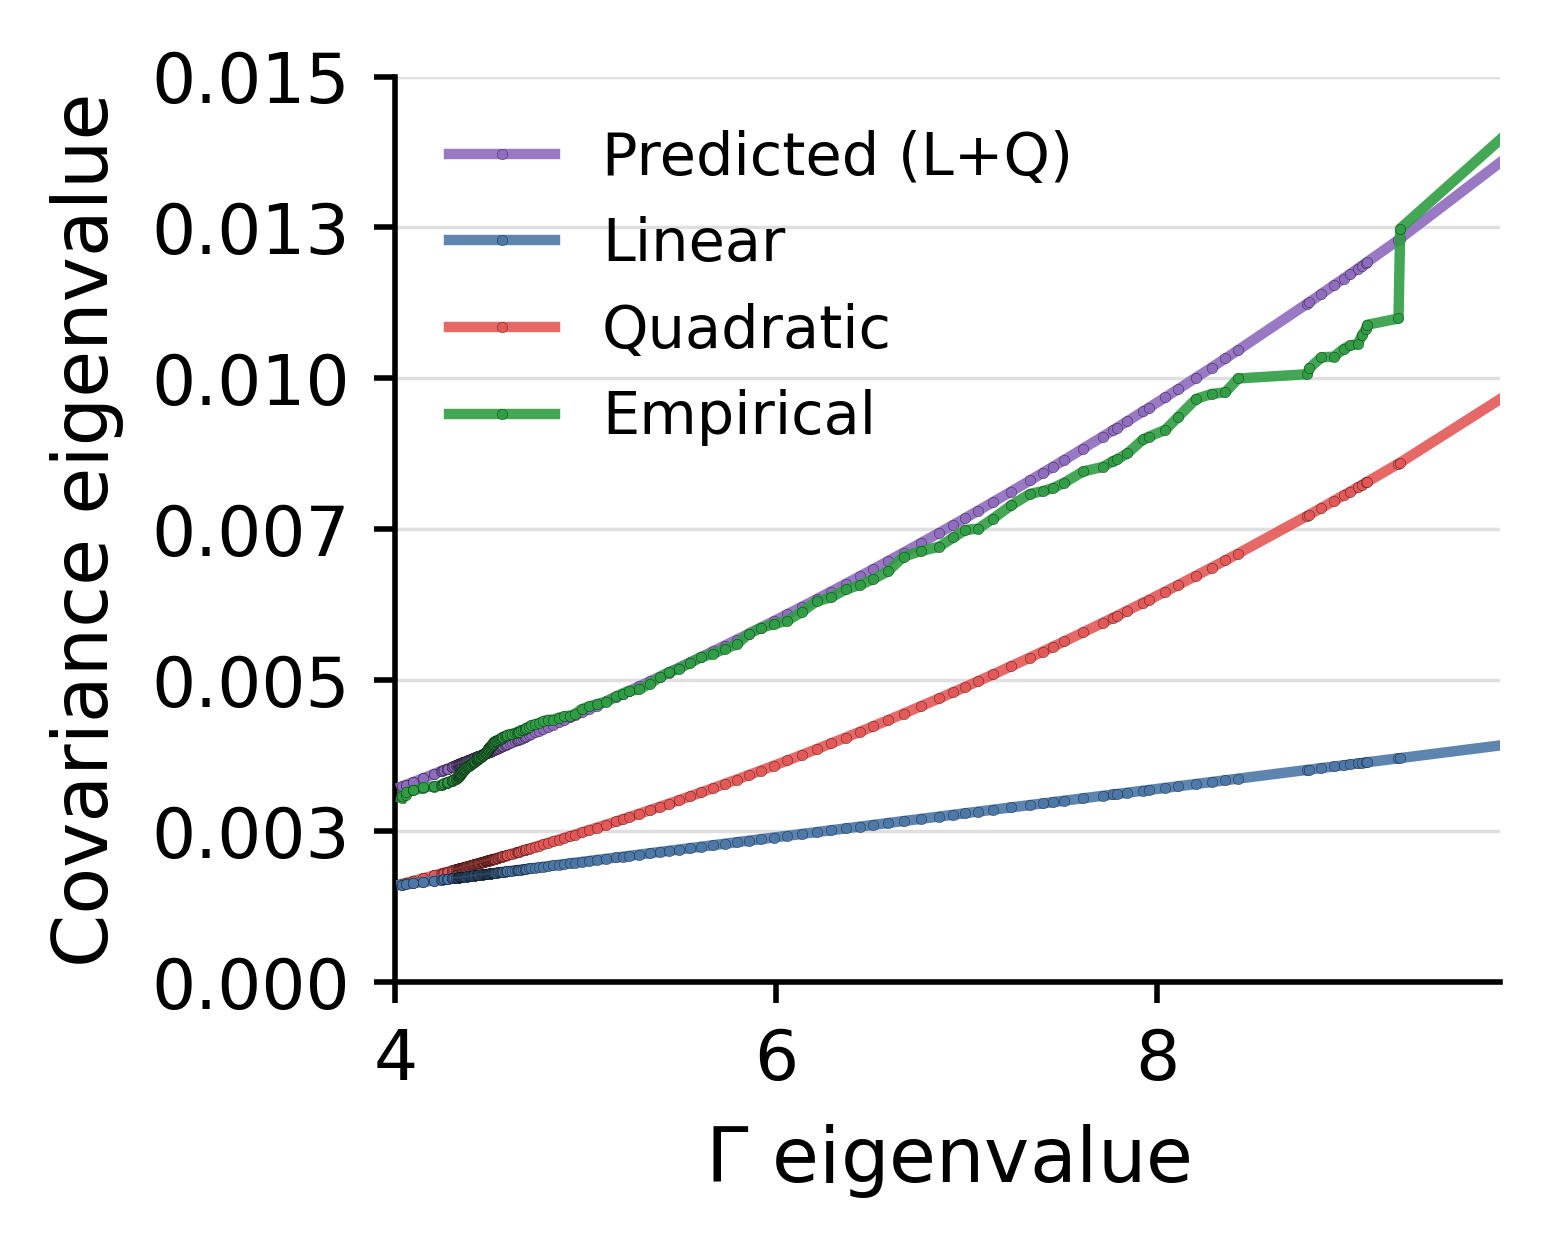

In [13]:
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

fig, ax = plt.subplots(figsize=(3.2, 2.6), dpi=500)


# for AMPAR in AMPAR_VALUES:
#     if AMPAR == 1.0:
#         RIN = 1.0
#     else:
#         RIN = 1.22
#     AMPAR ==1.0
AMPAR = 1.0
RIN = 1.0
TEMP = TEMP_VALUES[-1]
THETA = SIG_THETA_VALUES[-1]
ETA = ETA_VALUES[-1]
# for TEMP in TEMP_VALUES[::-1]:
#     if TEMP == 0.01: 
#         continue
#     for THETA in SIG_THETA_VALUES[::-1]:
#         for ETA in ETA_VALUES[::-1]:
state_one_angle = tensors[AMPAR, RIN, TEMP, ETA, THETA, RECURRENT_WIDTH_VALUES[0], ACTIVE_FRACTION_VALUES[0]][:,:,:,0]
Neurons, Generations, Trials = state_one_angle.shape

average_size = BLOCK_SIZE // 2
n_blocks = Generations // average_size  # integer division
cut = n_blocks * average_size             # how many generations to keep
data_trimmed = state_one_angle[:, :cut, :]
data_reshaped = data_trimmed.reshape(Neurons, n_blocks, average_size, Trials)
data_avg = data_reshaped.mean(axis=2)
data_avg = data_avg[:, :, :]
print(data_avg.shape)


state_one_angle = data_avg.reshape((Neurons, -1))
covariance_full = np.cov(state_one_angle)
eigenvalues_full, eigenvectors_full = np.linalg.eigh(covariance_full)

tau_gamma = BLOCK_SIZE          # you redraw gamma every 100 generations
L = average_size                # your averaging window (25)
f_T = 1.0 / L                   # first pass; refine with autocorr if needed
fac_gamma = min(tau_gamma, L) / L

Gamma = calculate_R_fast(state_one_angle, Neurons, TEMP, AMPAR, RIN, yes_t=True)  # this is your Γ
eigvals_gamma = np.linalg.eigvalsh(Gamma)

Sigma_pred = (
    f_T * TEMP * Gamma
    + fac_gamma * (THETA * AMPAR * RIN) ** 2 * (Gamma @ Gamma.T)
)

pred_linear = np.linalg.eigvalsh(f_T * TEMP * Gamma)
pred_quadratic = np.linalg.eigvalsh(
    fac_gamma * (THETA * AMPAR * RIN) ** 2 * (Gamma @ Gamma.T)
)
pred_full = np.linalg.eigvalsh(Sigma_pred)

ctr_color = "#4C78A8"         # muted blue
fr_color = "#E45756"          # muted red
comparison_color = "#8E6BBE"  # muted purple
green_color = "#2F9E44"       # muted green

# ax.plot(eigenvalues_full, 'o-', markersize=3, label=f'G={ETA}, Temp={TEMP}, Ampar={AMPAR}, Rin={RIN}')
ax.plot(
    eigvals_gamma,
    pred_full,
    "o-",
    color=comparison_color,
    lw=1.5,
    markersize=1.5,
    markeredgecolor="black",
    markeredgewidth=0.05,
    alpha=0.9,
    label="Predicted (L+Q)",
    zorder=4,
)

ax.plot(
    eigvals_gamma,
    pred_linear,
    "o-",
    color=ctr_color,
    lw=1.5,
    markersize=1.5,
    markeredgecolor="black",
    markeredgewidth=0.05,
    alpha=0.9,
    label="Linear",
    zorder=3,
)

ax.plot(
    eigvals_gamma,
    pred_quadratic,
    "o-",
    color=fr_color,
    lw=1.5,
    markersize=1.5,
    markeredgecolor="black",
    markeredgewidth=0.05,
    alpha=0.9,
    label="Quadratic",
    zorder=2,
)

ax.plot(
    eigvals_gamma,
    eigenvalues_full,
    "o-",
    color=green_color,
    lw=1.5,
    markersize=1.5,
    markeredgecolor="black",
    markeredgewidth=0.05,
    alpha=0.9,
    label="Empirical",
    zorder=5,
)

# ax.plot([0, 0.05], [0, 0.05], 'k--', lw=1)

ax.set_ylabel("Covariance eigenvalue")
ax.set_xlabel(r"$\Gamma$ eigenvalue")

ax.set_ylim(0, 0.015)
ax.set_xlim(4, 9.8)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.tick_params(direction="out", length=3, width=0.8)
ax.grid(axis="y", linewidth=0.5, alpha=0.4)
#make y ticks in sformat
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.3f}'))

ax.legend(
    frameon=False,
    fontsize=8.5,
    handlelength=1.8,
    loc="upper left",
)

fig.tight_layout()

# fig.savefig("covariance_prediction_vs_gamma.pdf", dpi=500, bbox_inches="tight")
plt.show()

(250, 60000, 1)
(250, 60000, 1)
(250, 60000, 1)
(250, 60000, 1)
(250, 60000, 1)
(250, 60000, 1)
(250, 60000, 1)
(250, 60000, 1)


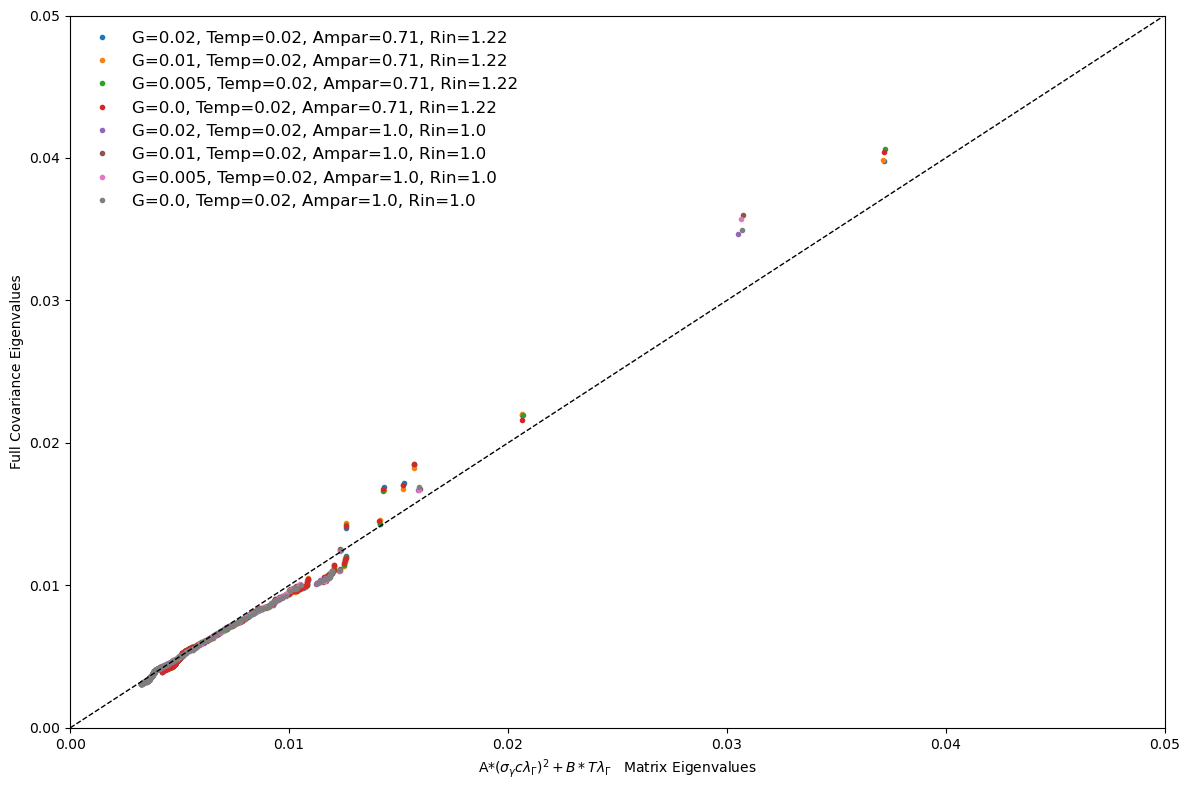

In [ ]:
# fig, ax = plt.subplots(figsize=(12, 8))

# # THETA = SIG_THETA_VALUES[0]
# # ETA= ETA_VALUES[0]
# for AMPAR in AMPAR_VALUES:
#     if AMPAR == 1.0:
#         RIN = 1.0
#     else:
#         RIN = 1.22

#     for TEMP in TEMP_VALUES[::-1]:
#         if TEMP == 0.01: 
#             continue
#         for THETA in SIG_THETA_VALUES[::-1]:
#             for ETA in ETA_VALUES[::-1]:
#                 state_one_angle = tensors[AMPAR, RIN, TEMP, ETA,THETA, RECURRENT_WIDTH_VALUES[0], ACTIVE_FRACTION_VALUES[0]][:,:,:,0]
#                 Neurons, Generations, Trials = state_one_angle.shape
                
#                 average_size = BLOCK_SIZE//2
#                 n_blocks = Generations // average_size  # integer division
#                 cut = n_blocks * average_size             # how many generations to keep
#                 data_trimmed = state_one_angle[:, :cut, :]
#                 data_reshaped = data_trimmed.reshape(Neurons, n_blocks, average_size, Trials)
#                 data_avg = data_reshaped.mean(axis=2)
#                 data_avg = data_avg[:, :, :]
#                 print(data_avg.shape)
                
                
#                 state_one_angle = data_avg.reshape((Neurons, -1))
#                 covariance_full = np.cov(state_one_angle)
#                 eigenvalues_full, eigenvectors_full = np.linalg.eigh(covariance_full)
    
#                 tau_gamma = BLOCK_SIZE          # you redraw gamma every 100 generations
#                 L = average_size         # your averaging window (25)
#                 f_T     = 1.0 / L                   # first pass; refine with autocorr if needed
#                 fac_gamma = min(tau_gamma, L) / L

#                 Gamma = calculate_R_fast(state_one_angle, Neurons, TEMP, AMPAR, RIN, yes_t = True)  # this is your Γ
#                 Sigma_pred = f_T*TEMP*Gamma +fac_gamma*(THETA*AMPAR*RIN)**2 * (Gamma @ Gamma.T) # predicted covariance from theory

#                 pred_full = np.linalg.eigvalsh(Sigma_pred)   # symmetric -> use eigvalsh
#                 ax.plot(pred_full,eigenvalues_full, 'o', markersize=3, label=f'G={ETA}, Temp={TEMP}, Ampar={AMPAR}, Rin={RIN}')

# ax.plot([0, 0.05], [0, 0.05], 'k--', lw=1)
# ax.set_ylabel("Full Covariance Eigenvalues")
# ax.set_xlabel(r"A*($\sigma_\gamma c \lambda_\Gamma)^2 + B*T\lambda_\Gamma$   Matrix Eigenvalues")
# plt.xlim(0.,0.05)
# plt.ylim(0.,0.05)  

# plt.legend(fontsize=12, frameon=False)
# fig.tight_layout()
# plt.show()

# Verification of Signal Vector

In [ ]:
def get_bump(idir, num_neurons, sigma_input, amplitude):
    center_index_tensor = np.full(num_neurons, int(idir*num_neurons))

    sigma_idx = sigma_input * num_neurons                        # width in *index* units
    d0 = np.arange(0, (num_neurons//2)+1)
    bump_LUT = np.exp(-0.5 * (d0 / sigma_idx)**2)  # size ≈ N/2+1
    distances = np.arange(num_neurons)
    distances = np.abs(distances - center_index_tensor)
    distances = np.minimum(distances, num_neurons - distances)
    input_bump_profile = amplitude* bump_LUT[distances]
    return input_bump_profile
def calculate_R_fast_conserved(state, N, T, ampar, rin, yes_t):
    # Build the same W you assume in theory
    threshold_active_fraction = RECURRENT_WIDTH_VALUES[0]
    idx = np.arange(N)
    diff = np.abs(idx[:, None] - idx[None, :])
    diff = np.minimum(diff, N - diff)
    threshold = threshold_active_fraction * N / 2.0
    W = (diff <= threshold).astype(float) / N
    np.fill_diagonal(W, 0.0)

    m = state.mean(axis=1)  # <s_i>
    if T <= 0:
        raise ValueError("Mean-field D needs T>0; for T=0 use empirical cov or treat separately.")
    if yes_t:
        D = np.diag(m * (1 - m))/T
    else:
        D = np.diag(m * (1 - m))

    c = rin * ampar
    A = np.eye(N) - c * (D @ W)

    # Base (unconstrained) response to b
    # Rb = A^{-1} D
    Rb = np.linalg.solve(A, D)

    # Enforce sum_i δm_i = 0  (activity conservation)
    one = np.ones((N, 1))
    u = (one.T @ Rb)               # shape (1,N)
    v = (Rb @ one)                 # shape (N,1)
    denom = float(one.T @ v)       # scalar
    Rb_cons = Rb - (v @ u) / denom

    # If you want response to "I" where δb = rin * δI (your earlier convention),
    # return R = Rb_cons * rin
    return Rb_cons# Rb_cons * rin


def proj_zero_sum(v):
    return v - v.mean()
ETA = ETA_VALUES[1]
fig, ax = plt.subplots(figsize=(6, 4))
for ETA in ETA_VALUES[::-1]:
    for THETA in SIG_THETA_VALUES[::-1]:
        for AMPAR in AMPAR_VALUES:
            if AMPAR == 1.0:
                RIN = 1.0
            else:
                RIN = 1.22
            for TEMP in TEMP_VALUES[::-1]:
                if TEMP == 0.01:
                    continue
                for THETA in SIG_THETA_VALUES[::-1]:
                    idir1 = 0 
                    neurons = tensors[AMPAR, RIN, TEMP, ETA,THETA, RECURRENT_WIDTH_VALUES[0], ACTIVE_FRACTION_VALUES[0]].shape[0]
                    state1 = tensors[AMPAR, RIN, TEMP, ETA,THETA, RECURRENT_WIDTH_VALUES[0], ACTIVE_FRACTION_VALUES[0]][:,:,:,idir1].reshape((neurons, -1))
                    mu1 = tensors[AMPAR, RIN, TEMP, ETA,THETA, RECURRENT_WIDTH_VALUES[0], ACTIVE_FRACTION_VALUES[0]][:,:,:,idir1].mean(axis=(1,2))

                    linear_response = calculate_R_fast_conserved(state1, neurons, TEMP, AMPAR, RIN, True)
                    idir2= 1
                    # for idir2 in range(len(IDIR_VALUES)):
                    if idir1 == idir2:
                        continue
                    mu2 = tensors[AMPAR, RIN, TEMP, ETA,THETA, RECURRENT_WIDTH_VALUES[0], ACTIVE_FRACTION_VALUES[0]][:,:,:,idir2].mean(axis=(1,2))
                    delta_mu = mu1 - mu2
                    delta_mu = delta_mu - delta_mu.mean()
                    delta_x = get_bump(IDIR_VALUES[idir1], neurons,I_SIGMA_VALUES[0], I_STR_VALUES[0]) - get_bump(IDIR_VALUES[idir2], neurons, I_SIGMA_VALUES[0], I_STR_VALUES[0])
                    delta_x = delta_x 
                    delta_mu_estimate = AMPAR*RIN*linear_response @ delta_x
                    # delta_mu_estimate = delta_mu_estimate-delta_mu_estimate.mean()
                    # print(delta_mu_estimate.sum(), delta_mu.sum())
                    plt.plot(delta_mu, delta_mu_estimate,"o" )#, label=f'gamma={THETA}, Temp={TEMP}, Ampar={AMPAR}, Rin={RIN}, idir2={IDIR_VALUES[idir2]}')
                    #Compare Norms 
                    print('AMPAR:', AMPAR, 'RIN:', RIN, 'TEMP:', TEMP, 'THETA:', THETA, 'idir2:', IDIR_VALUES[idir2])
                    print(f'Norm delta mu: {np.linalg.norm(delta_mu)}, Norm delta mu estimate: {np.linalg.norm(delta_mu_estimate)}')
                

ax.plot([-.04, 0.04], [-.04, 0.04], 'k--', lw=2)
# plt.xlim(0,0.5)
# plt.ylim(0,0.3)
plt.legend()
fig.tight_layout()
plt.xlabel(r"True $\Delta \mu$ ")
plt.ylabel(r"Estimated $\Delta \mu$")
plt.show()

# DMU plot

In [ ]:
#Plotting \Delta mu norm for different delta theta values
for ETA in ETA_VALUES:
    for TEMP in TEMP_VALUES:
        for SIG_THETA in SIG_THETA_VALUES:
            DIR1 = 0.5
            DMU_FR = []
            DMU_CTR = []
            for DIR2 in IDIR_VALUES:
                #For CTR
                MU1  = tensors[1,1,TEMP,ETA,SIG_THETA,RECURRENT_WIDTH_VALUES[0],ACTIVE_FRACTION_VALUES[0]][:,:,0, IDIR_VALUES.index(DIR1)].mean(axis=1)
                MU2 = tensors[1,1,TEMP,ETA,SIG_THETA,RECURRENT_WIDTH_VALUES[0],ACTIVE_FRACTION_VALUES[0]][:,:,0, IDIR_VALUES.index(DIR2)].mean(axis=1)        
                DMU_CTR.append(np.linalg.norm(MU1 - MU2))
                #For FR
                MU1  = tensors[0.71,1.22,TEMP,ETA,SIG_THETA,RECURRENT_WIDTH_VALUES[0],ACTIVE_FRACTION_VALUES[0]][:,:,0, IDIR_VALUES.index(DIR1)].mean(axis=1)
                MU2 = tensors[0.71,1.22,TEMP,ETA,SIG_THETA,RECURRENT_WIDTH_VALUES[0],ACTIVE_FRACTION_VALUES[0]][:,:,0, IDIR_VALUES.index(DIR2)].mean(axis=1)        
                DMU_FR.append(np.linalg.norm(MU1 - MU2))
            plt.plot(np.array(DMU_CTR), 'x--',color = 'blue',label=f"TEMP={TEMP}, ETA={ETA}, SIG_THETA={SIG_THETA}")
            plt.plot(np.array(DMU_FR), 'x--',color = 'red',label=f"TEMP={TEMP}, ETA={ETA}, SIG_THETA={SIG_THETA}")
            plt.legend()
            plt.xlabel(r"$\Delta \theta$")
            plt.ylabel(r"$\|\Delta \mu\|$")
            plt.show()
# plt.axhline(y=1, color='gray', linestyle='--', lw=0.8)
# plt.legend()
# plt.xlabel(r"$\Delta \theta$")
# plt.ylabel(r"$\|\Delta \mu\|$ CTR/FR")
#             # plt.plot(DTHETA, DMU_FR, 's--',label=f"TEMP={TEMP}, ETA={ETA}, SIG_THETA={SIG_THETA}")

# Fake Overlap vs Eval plot

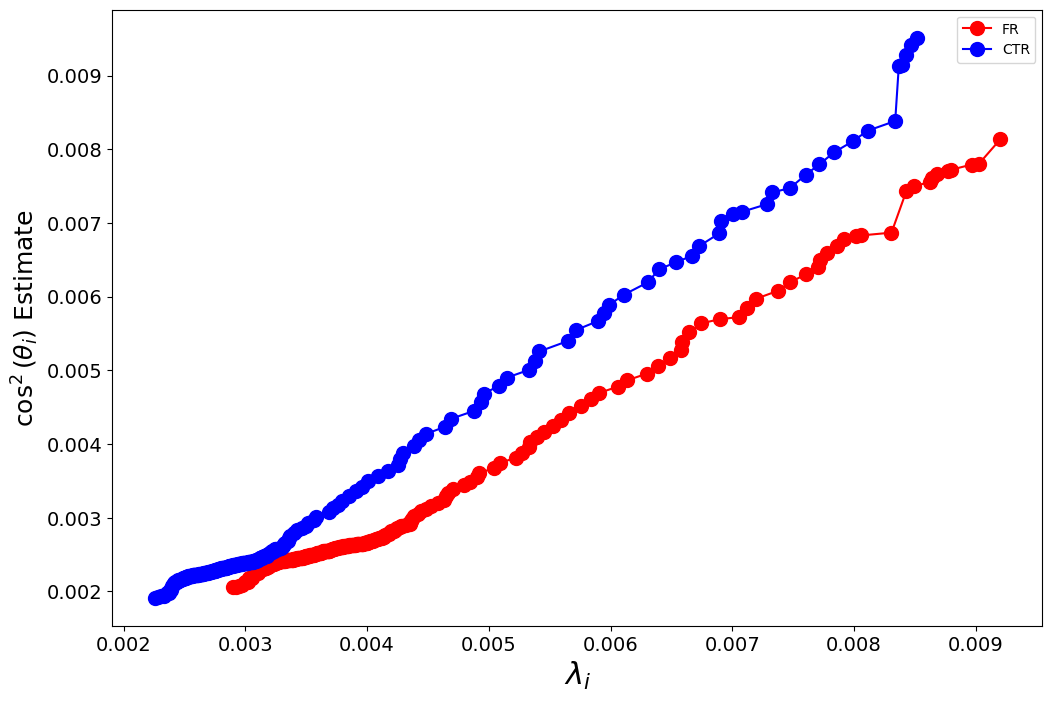

In [11]:
fig, ax = plt.subplots(figsize=(12, 8))

# THETA = SIG_THETA_VALUES[0]
# ETA= ETA_VALUES[0]
for AMPAR in AMPAR_VALUES:
    if AMPAR == 1.0:
        RIN = 1.0
    else:
        RIN = 1.22
    THETA = SIG_THETA_VALUES[0]
    ETA = ETA_VALUES[1]
    TEMP = TEMP_VALUES[0]
    # for TEMP in TEMP_VALUES[::-1]:
    #     if TEMP == 0.01:
    #         continue
    #     for THETA in SIG_THETA_VALUES[::-1]:
    #         for ETA in ETA_VALUES[::-1]:
    state_one_angle = tensors[AMPAR, RIN, TEMP, ETA,THETA, RECURRENT_WIDTH_VALUES[0], ACTIVE_FRACTION_VALUES[0]][:,:,:,0]
    Neurons, Generations, Trials = state_one_angle.shape
    average_size = BLOCK_SIZE
    
    n_blocks = Generations // average_size  # integer division
    cut = n_blocks * average_size             # how many generations to keep
    data_trimmed = state_one_angle[:, :cut, :]
    data_reshaped = data_trimmed.reshape(Neurons, n_blocks, average_size, Trials)
    data_avg = data_reshaped.mean(axis=2)
    data_avg = data_avg[:, :, :]
    
    
    state_one_angle = data_avg.reshape((Neurons, -1))
    covariance_full = np.cov(state_one_angle)
    eigenvalues_full, eigenvectors_full = np.linalg.eigh(covariance_full)

    tau_gamma = BLOCK_SIZE          # you redraw gamma every 100 generations
    L = average_size         # your averaging window (25)
    f_T     = 1.0 / L                   # first pass; refine with autocorr if needed
    fac_gamma = min(tau_gamma, L) / L

    Gamma = calculate_R_fast(state_one_angle, Neurons, TEMP, AMPAR, RIN, yes_t = True)  # this is your Γ
    # Sigma_pred = fac_gamma*(THETA*AMPAR*RIN)**2 * (Gamma @ Gamma.T)+f_T*TEMP*Gamma #  COMMENT OUT THE 2nd term to GET PARITY !!!
    # pred_full = np.linalg.eigvalsh(Sigma_pred)   # symmetric -> use eigvalsh
    
    # idir1 = 0
    # idir2= 1
    # mu2 = tensors[AMPAR, RIN, TEMP, ETA,THETA, RECURRENT_WIDTH_VALUES[0], ACTIVE_FRACTION_VALUES[0]][:,:,:,idir2].mean(axis=(1,2))
    # mu1 = tensors[AMPAR, RIN, TEMP, ETA,THETA, RECURRENT_WIDTH_VALUES[0], ACTIVE_FRACTION_VALUES[0]][:,:,:,idir1].mean(axis=(1,2))
    # delta_mu = mu1 - mu2
    # actual_overlap = np.dot(delta_mu, eigenvectors_full)**2
    # actual_cos = np.dot(delta_mu, eigenvectors_full)**2/(np.linalg.norm(delta_mu)**2) 

    gamma_evals = np.linalg.eigvalsh(Gamma)
    fake_overlap_estimate = (AMPAR*RIN*gamma_evals)**2
    fake_cos_estimate = (AMPAR*RIN*gamma_evals)**2/(np.sum((AMPAR*RIN*gamma_evals)**2))

    # delta_x = get_bump(IDIR_VALUES[idir1], neurons,I_SIGMA_VALUES[0], I_STR_VALUES[0]) - get_bump(IDIR_VALUES[idir2], neurons, I_SIGMA_VALUES[0], I_STR_VALUES[0])
    # delta_mu_estimate = (AMPAR*RIN*gamma_evals*(eigenvectors_full.T @ delta_x))**2
    if AMPAR!=1.0:
        color = 'red'
        label = 'FR'
    else:
        color = 'blue'
        label = 'CTR'
    plt.plot(eigenvalues_full[:-10], (fake_cos_estimate)[:-10], "o-", markersize = 10, label = label, color=color)

# plt.xscale('log')
# plt.yscale('log')
plt.tick_params(axis='both', which='major', labelsize=14)
plt.xlabel(r"$\lambda_i$", fontsize=22)
# plt.ylabel(r"$(v_i \cdot \Delta \mu)^2$ Estimate", fontsize=18)
plt.ylabel(r"$\cos^2(\theta_i)$ Estimate", fontsize=18)
plt.legend()


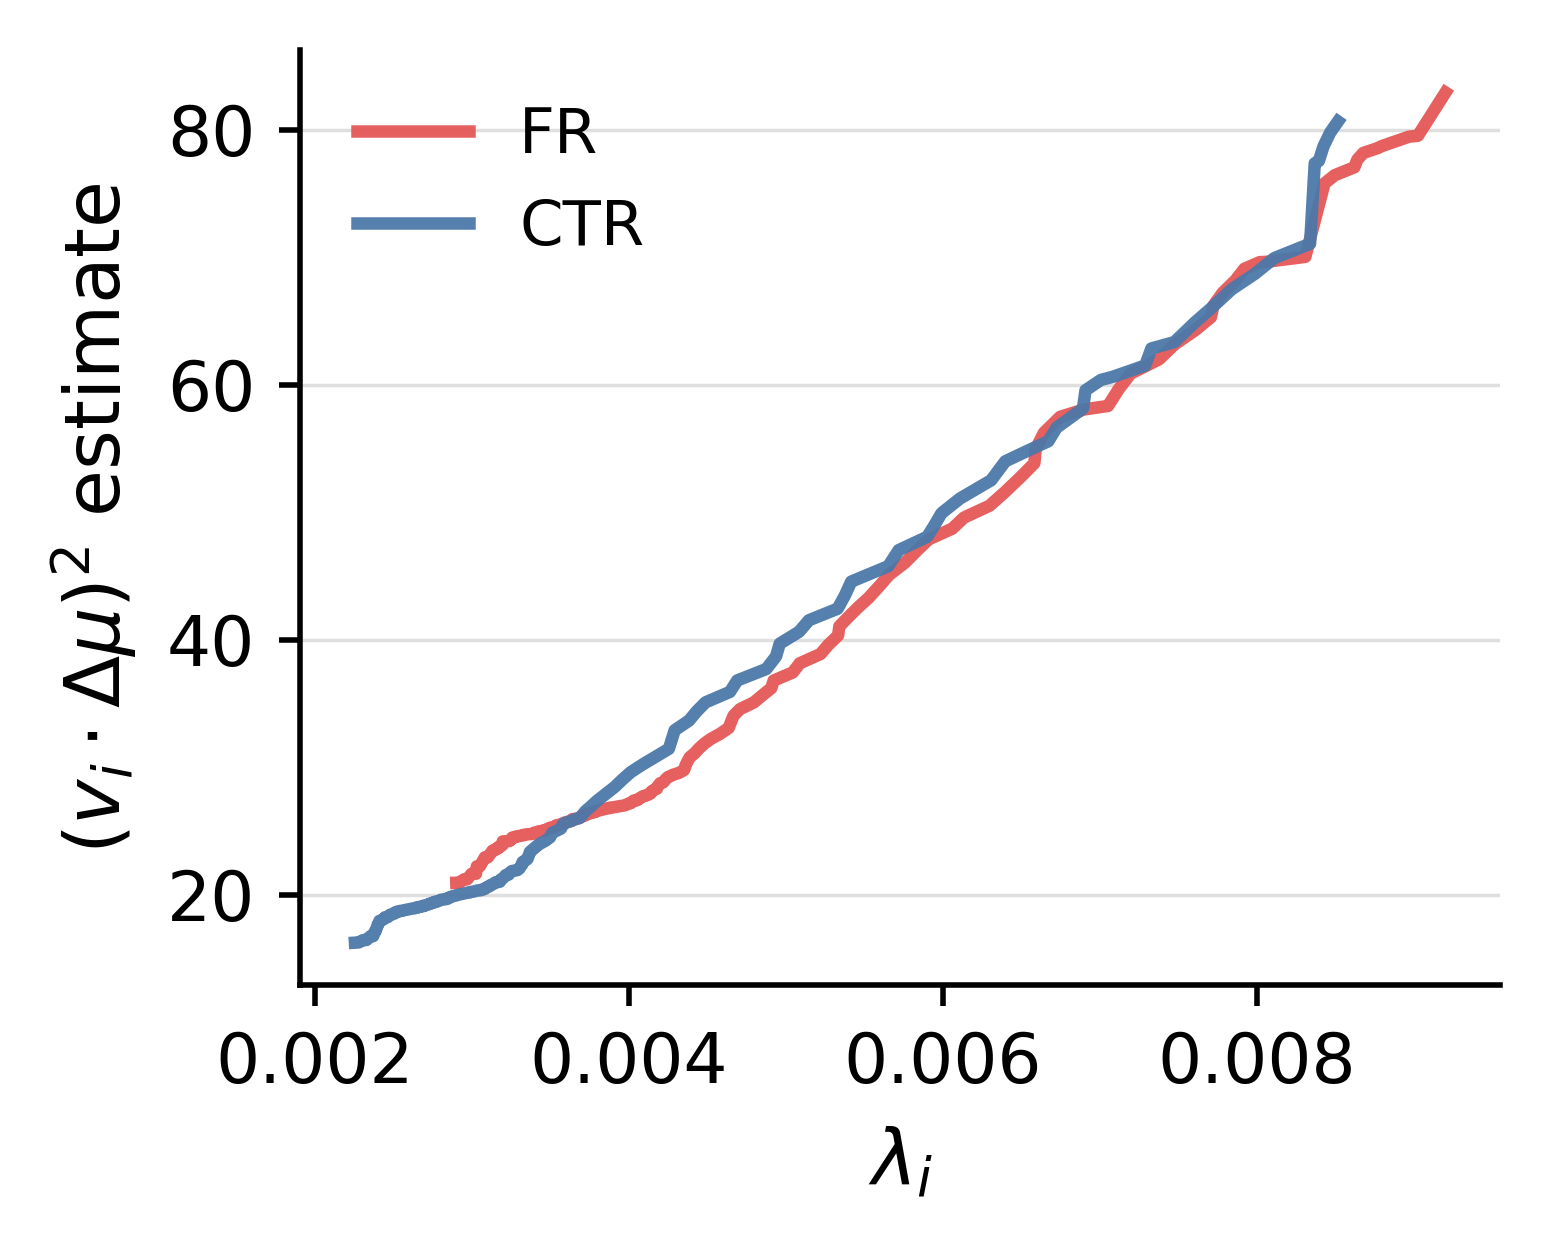

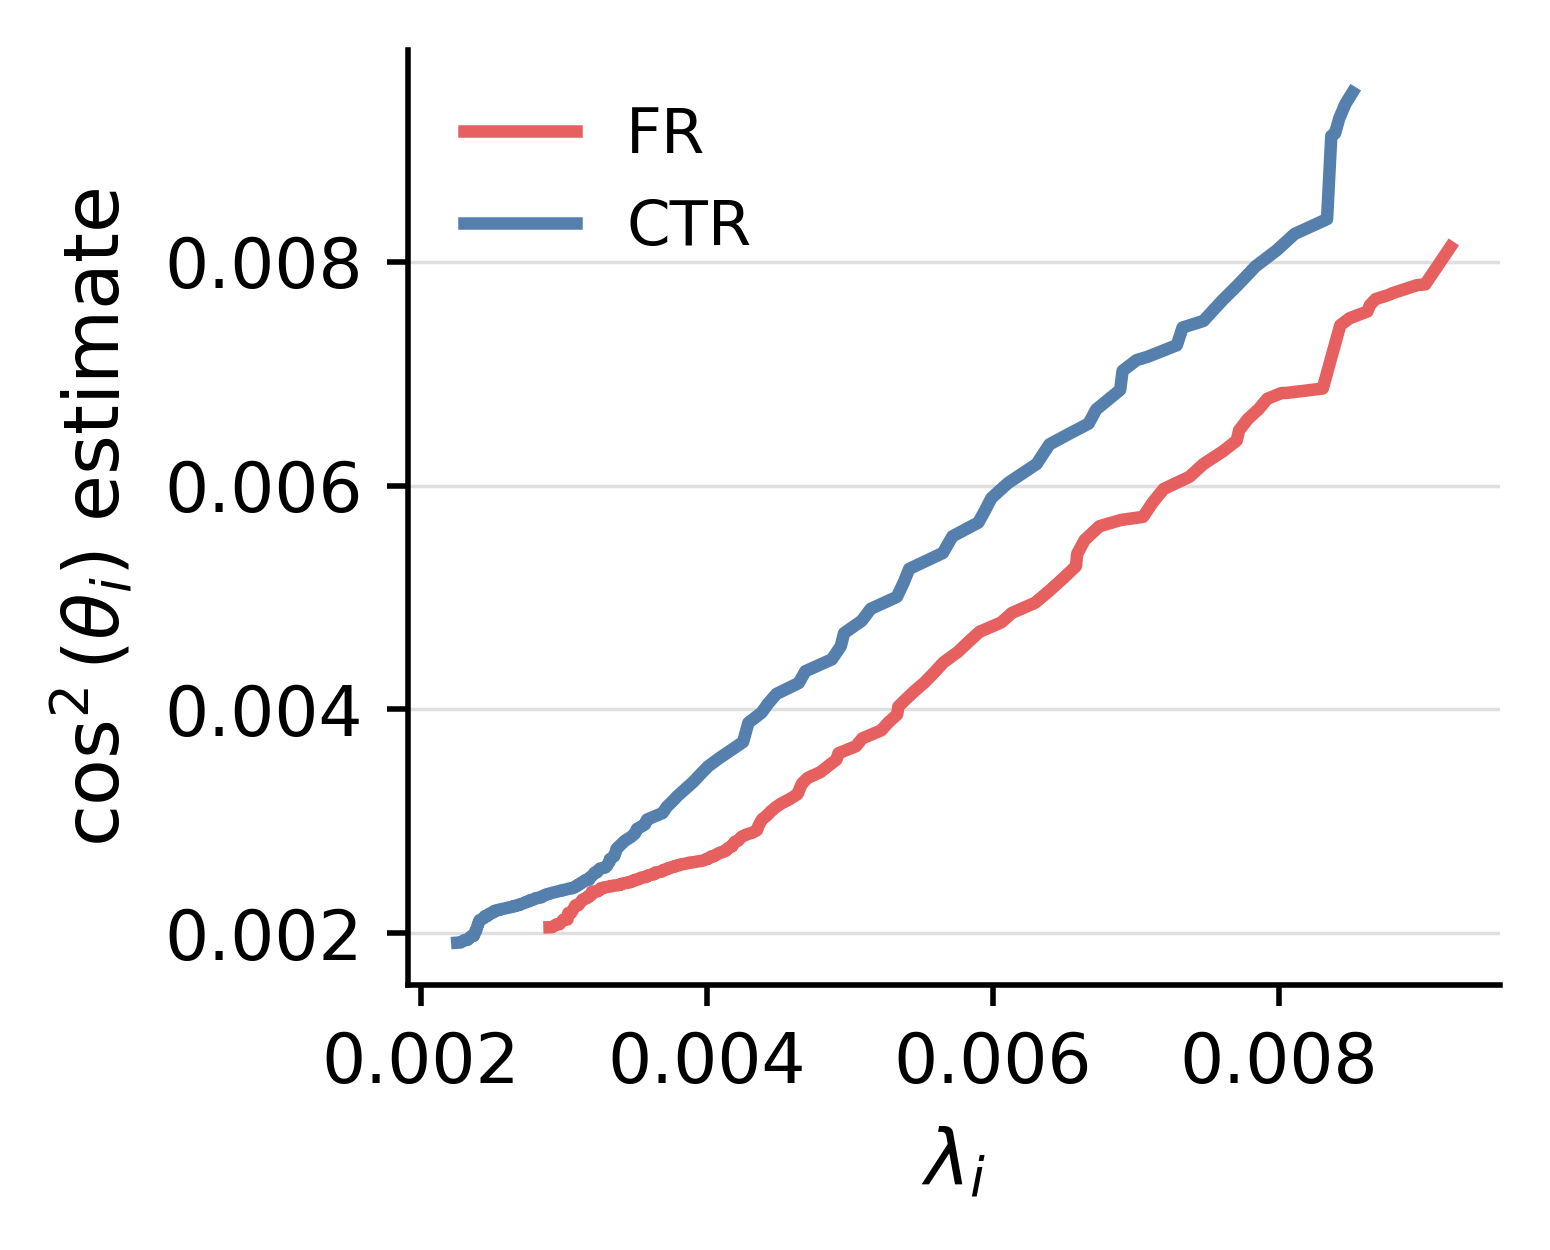

In [12]:
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

ctr_color = "#4C78A8"   # muted blue
fr_color = "#E45756"    # muted red

fig1, ax1 = plt.subplots(figsize=(3.2, 2.6), dpi=500)
fig2, ax2 = plt.subplots(figsize=(3.2, 2.6), dpi=500)

# THETA = SIG_THETA_VALUES[0]
# ETA = ETA_VALUES[0]
for AMPAR in AMPAR_VALUES:
    if AMPAR == 1.0:
        RIN = 1.0
    else:
        RIN = 1.22

    THETA = SIG_THETA_VALUES[0]
    ETA = ETA_VALUES[1]
    TEMP = TEMP_VALUES[0]

    state_one_angle = tensors[
        AMPAR, RIN, TEMP, ETA, THETA,
        RECURRENT_WIDTH_VALUES[0],
        ACTIVE_FRACTION_VALUES[0]
    ][:, :, :, 0]

    Neurons, Generations, Trials = state_one_angle.shape
    average_size = BLOCK_SIZE

    n_blocks = Generations // average_size
    cut = n_blocks * average_size
    data_trimmed = state_one_angle[:, :cut, :]
    data_reshaped = data_trimmed.reshape(Neurons, n_blocks, average_size, Trials)
    data_avg = data_reshaped.mean(axis=2)
    data_avg = data_avg[:, :, :]

    state_one_angle = data_avg.reshape((Neurons, -1))
    covariance_full = np.cov(state_one_angle)
    eigenvalues_full, eigenvectors_full = np.linalg.eigh(covariance_full)

    tau_gamma = BLOCK_SIZE
    L = average_size
    f_T = 1.0 / L
    fac_gamma = min(tau_gamma, L) / L

    Gamma = calculate_R_fast(
        state_one_angle,
        Neurons,
        TEMP,
        AMPAR,
        RIN,
        yes_t=True,
    )

    gamma_evals = np.linalg.eigvalsh(Gamma)
    fake_overlap_estimate = (AMPAR * RIN * gamma_evals) ** 2
    fake_cos_estimate = (
        (AMPAR * RIN * gamma_evals) ** 2
        / np.sum((AMPAR * RIN * gamma_evals) ** 2)
    )

    if AMPAR != 1.0:
        color = fr_color
        label = "FR"
    else:
        color = ctr_color
        label = "CTR"

    x = eigenvalues_full[:-10]
    y_overlap = fake_overlap_estimate[:-10]
    y_cos = fake_cos_estimate[:-10]

    # overlap panel
    ax1.plot(
        x,
        y_overlap,
        "-",
        color=color,
        lw=1.8,
        alpha=0.95,
        label=label,
    )

    # cos^2 panel
    ax2.plot(
        x,
        y_cos,
        "-",
        color=color,
        lw=1.8,
        alpha=0.95,
        label=label,
    )


# ---------- overlap plot ----------
ax1.set_xlabel(r"$\lambda_i$")
ax1.set_ylabel(r"$(v_i \cdot \Delta \mu)^2$ estimate")

ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.tick_params(direction="out", length=3, width=0.8)
ax1.grid(axis="y", linewidth=0.5, alpha=0.4)
ax1.legend(frameon=False, fontsize=9, handlelength=1.8, loc="best")

fig1.tight_layout()


# ---------- cos^2 plot ----------
ax2.set_xlabel(r"$\lambda_i$")
ax2.set_ylabel(r"$\cos^2(\theta_i)$ estimate")

ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.tick_params(direction="out", length=3, width=0.8)
ax2.grid(axis="y", linewidth=0.5, alpha=0.4)
ax2.legend(frameon=False, fontsize=9, handlelength=1.8, loc="best")

fig2.tight_layout()

# fig1.savefig("overlap_estimate_vs_lambda.pdf", dpi=500, bbox_inches="tight")
# fig2.savefig("cos2_estimate_vs_lambda.pdf", dpi=500, bbox_inches="tight")

plt.show()

# Dynamic analysis

In [3]:
print(TEMP_VALUES)
print(SIG_THETA_VALUES)
print(ETA_VALUES)

[0.02]
[0.01]
[0.01]


In [20]:
def snr_for_window(state_one_angle, t0, t1):
    X1 = state_one_angle[:, t0:t1, :, 0].mean(axis=1)
    X2 = state_one_angle[:, t0:t1, :, 1].mean(axis=1)

    mu1 = X1.mean(axis=1, keepdims=True)
    mu2 = X2.mean(axis=1, keepdims=True)
    delta = (mu1 - mu2).ravel()

    R = np.concatenate([X1 - mu1, X2 - mu2], axis=1)
    covariance = R @ R.T / (R.shape[1] - 2)


    alpha = 0.05
    scale = np.trace(covariance) / covariance.shape[0]
    covariance_reg = (1 - alpha) * covariance + alpha * scale * np.eye(covariance.shape[0])

    # covariance_reg = np.cov(X1)
    # print(covariance_reg.shape, delta.shape)

    snr = delta.T @ np.linalg.solve(covariance_reg, delta)
    return snr



TEMP = TEMP_VALUES[-1]
THETA = SIG_THETA_VALUES[-1]
ETA = ETA_VALUES[-1]
window = 50
stride = 200  # evaluate every 100 time bins instead of every bin

ctr_snr = []
fr_snr = []
times = []

ctr_state = tensors[0.71, 1.0, TEMP, ETA, THETA,
                    RECURRENT_WIDTH_VALUES[0],
                    ACTIVE_FRACTION_VALUES[0]][:,:,:,:]

fr_state = tensors[0.71, 1.22, TEMP, ETA, THETA,
                   RECURRENT_WIDTH_VALUES[0],
                   ACTIVE_FRACTION_VALUES[0]][:,:,:,:]
print(ctr_state.shape)
for t0 in range(0, ctr_state.shape[1] - window + 1, stride):
    t1 = t0 + window
    times.append((t0 + t1) / 2)

    ctr_snr.append(snr_for_window(ctr_state, t0, t1))
    fr_snr.append(snr_for_window(fr_state, t0, t1))




(150, 10000, 1000, 2)


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


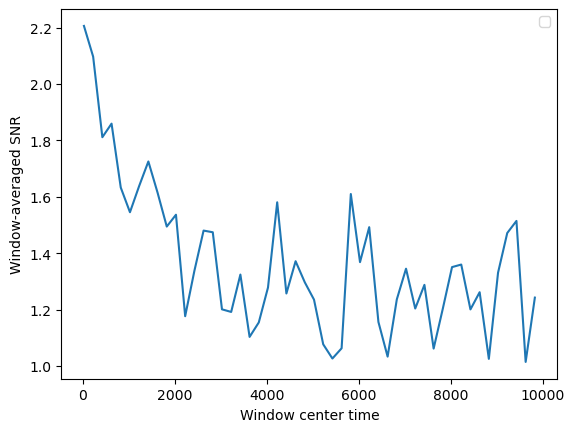

In [22]:
ctr_snr = np.array(ctr_snr)
fr_snr = np.array(fr_snr)
# plt.plot(times, fr_snr, color = 'red', label="FR")
# plt.plot(times, ctr_snr, color = 'blue', label="CTR")
plt.plot(times, fr_snr/ctr_snr)
# plt.plot(times, , label="FR")
plt.xlabel("Window center time")
plt.ylabel("Window-averaged SNR")
plt.legend()

Fr
[0.01625    0.01624865 0.0162473  0.01624595 0.0162446  0.01624325
 0.0162419  0.01624055 0.0162392  0.01623785]
0.012
0.01
ctr
[0.013     0.0129997 0.0129994 0.0129991 0.0129988 0.0129985 0.0129982
 0.0129979 0.0129976 0.0129973]
0.012
0.01


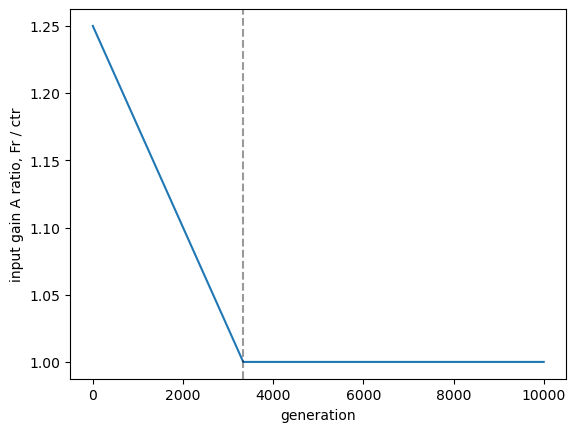

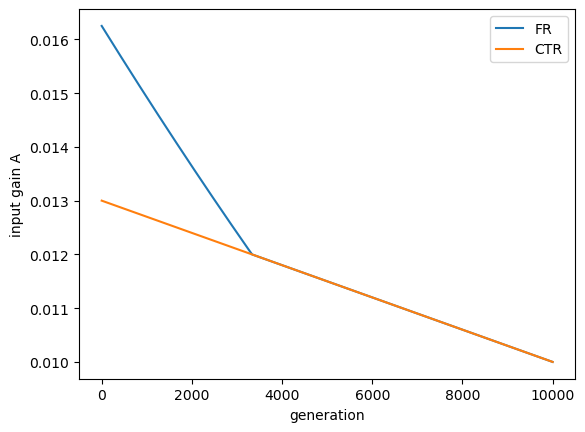

In [ ]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt


# RUNS_DIR = Path("/DATA/scastedo/runs_may_14_test_2")

RUN_DIRS = {
    "Fr": RUNS_DIR / "ampar0.71_rin1.22_sigtemp0.02_sigeta0_sigtheta0_idir0.5_cwidth0.1_afrac0.1_pswap0.6_dbfr0.008_gaindyn1_trial00",
    "ctr": RUNS_DIR / "ampar1_rin1_sigtemp0.02_sigeta0_sigtheta0_idir0.5_cwidth0.1_afrac0.1_pswap0.6_dbfr0.008_gaindyn1_trial00",
}


CONTROL_START = 1.3
CONTROL_END = 1.0

FR_CTR_RATIO_START = 1.25
FR_CTR_RATIO_END = 1.0
FR_CTR_RATIO_DECAY_FRACTION = 1 / 3


def control_gain(gen: int, num_generations: int) -> float:
    """Control gain smoothly decreases from 1.5 to 1.0."""
    if num_generations <= 1:
        return CONTROL_END

    t = gen / (num_generations - 1)
    return CONTROL_START + (CONTROL_END - CONTROL_START) * t


def fr_ctr_ratio(gen: int, num_generations: int) -> float:
    """FR/control ratio goes from 1.25 to 1.1 by 1/3 of the run, then stays flat."""
    end_gen = max(1, int(num_generations * FR_CTR_RATIO_DECAY_FRACTION))
    progress = min(gen / end_gen, 1.0)

    return FR_CTR_RATIO_START + (FR_CTR_RATIO_END - FR_CTR_RATIO_START) * progress


def gain_multiplier(gen: int, num_generations: int, food_restricted: bool) -> float:
    gain = control_gain(gen, num_generations)

    if food_restricted:
        gain *= fr_ctr_ratio(gen, num_generations)

    return gain


def load_gain_A(run_dir: Path) -> tuple[np.ndarray, int]:
    meta = json.loads((run_dir / "run_metadata.json").read_text())

    num_generations = meta["spec"]["num_generations"]
    i_str = meta["network_params"]["I_str"]
    food_restricted = meta["spec"]["rin"] != 1.0

    gain_A = np.array([
        i_str * gain_multiplier(gen, num_generations, food_restricted)
        for gen in range(num_generations)
    ])

    return gain_A, num_generations


gain_A = {}

for label, run_dir in RUN_DIRS.items():
    gain_A[label], num_generations = load_gain_A(run_dir)

    print(label)
    print(gain_A[label][:10])
    print(gain_A[label][num_generations // 3])
    print(gain_A[label][-1])


ratio = gain_A["Fr"] / gain_A["ctr"]

plt.plot(ratio)
plt.axvline(len(ratio) / 3, color="k", linestyle="--", alpha=0.4)
plt.xlabel("generation")
plt.ylabel("input gain A ratio, Fr / ctr")
# plt.ylim(1.05, 1.30)
plt.show()


plt.plot(gain_A["Fr"], label="FR")
plt.plot(gain_A["ctr"], label="CTR")
plt.xlabel("generation")
plt.ylabel("input gain A")
plt.legend()
plt.show()

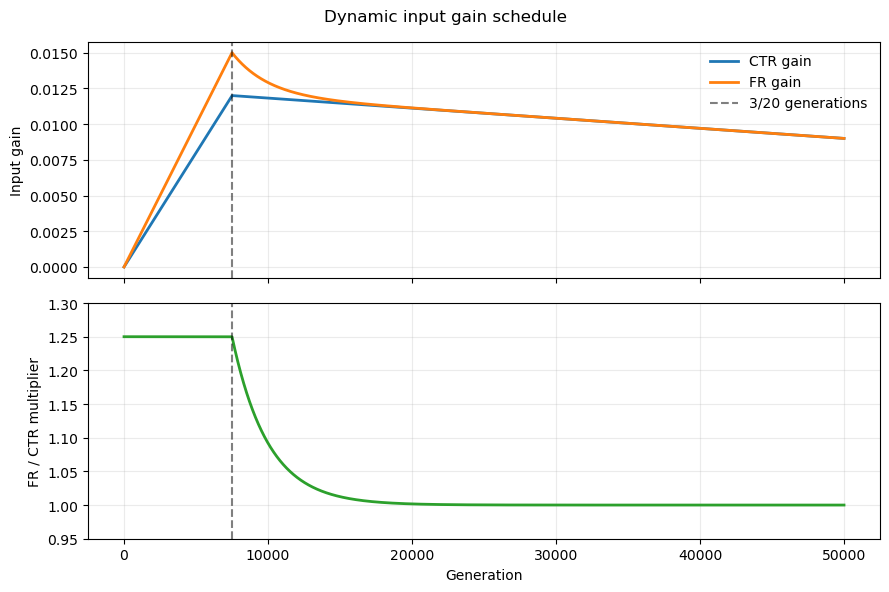

Peak generation: 7,500 / 50,000
CTR start/peak/end: 0.000000, 0.012000, 0.009000
FR  start/peak/end: 0.000000, 0.015000, 0.009000
FR/CTR peak/end: 1.250, 1.000


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ---- Schedule parameters ----
num_generations = 50_000

peak_fraction = 3 / 20
ctr_start_gain = 0.0
ctr_peak_gain = 0.012
ctr_end_gain = 0.009

fr_start_ratio = 1.25
fr_end_ratio = 1.0

# Smaller = faster drop after 3/20.
# 0.01 means the FR multiplier is almost back to 1 within ~1% of total generations.
ratio_tau_fraction = 0.05

# ---- Build trajectories ----
gens = np.arange(num_generations)
progress = gens / (num_generations - 1)
peak_gen = int(round(peak_fraction * (num_generations - 1)))

ctr_gain = np.empty_like(progress, dtype=float)
fr_ratio = np.empty_like(progress, dtype=float)

before_peak = progress <= peak_fraction
after_peak = ~before_peak

# CTR: 0 -> 0.012 over first 3/20
ctr_gain[before_peak] = np.interp(
    progress[before_peak],
    [0.0, peak_fraction],
    [ctr_start_gain, ctr_peak_gain],
)

# CTR: 0.012 -> 0.009 over remaining generations
ctr_gain[after_peak] = np.interp(
    progress[after_peak],
    [peak_fraction, 1.0],
    [ctr_peak_gain, ctr_end_gain],
)

# FR: exactly 1.25x CTR for first 3/20
fr_ratio[before_peak] = fr_start_ratio

# FR: quickly decays from 1.25 to 1.0 after 3/20
after_progress = progress[after_peak] - peak_fraction
fr_ratio[after_peak] = fr_end_ratio + (
    fr_start_ratio - fr_end_ratio
) * np.exp(-after_progress / ratio_tau_fraction)

fr_gain = ctr_gain * fr_ratio

# ---- Plot ----
fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

axes[0].plot(gens, ctr_gain, label="CTR gain", linewidth=2)
axes[0].plot(gens, fr_gain, label="FR gain", linewidth=2)
axes[0].axvline(peak_gen, color="black", linestyle="--", alpha=0.5, label="3/20 generations")
axes[0].set_ylabel("Input gain")
axes[0].legend(frameon=False)
axes[0].grid(alpha=0.25)

axes[1].plot(gens, fr_ratio, color="tab:green", linewidth=2)
axes[1].axvline(peak_gen, color="black", linestyle="--", alpha=0.5)
axes[1].set_ylabel("FR / CTR multiplier")
axes[1].set_xlabel("Generation")
axes[1].set_ylim(0.95, 1.30)
axes[1].grid(alpha=0.25)

fig.suptitle("Dynamic input gain schedule")
plt.tight_layout()
plt.show()

print(f"Peak generation: {peak_gen:,} / {num_generations:,}")
print(f"CTR start/peak/end: {ctr_gain[0]:.6f}, {ctr_gain[peak_gen]:.6f}, {ctr_gain[-1]:.6f}")
print(f"FR  start/peak/end: {fr_gain[0]:.6f}, {fr_gain[peak_gen]:.6f}, {fr_gain[-1]:.6f}")
print(f"FR/CTR peak/end: {fr_ratio[peak_gen]:.3f}, {fr_ratio[-1]:.3f}")

Text(0.5, 0, 'Time (s)')

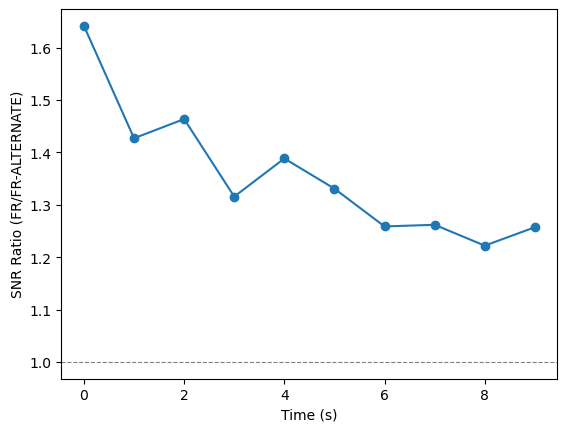

In [82]:
ratio = fr_snr / ctr_snr
# bin average the ratio
ratio_binned = []
for i in range(0, len(ratio), 10):
    ratio_binned.append(np.mean(ratio[i:i+10]))


plt.plot(ratio_binned, "o-",label="SNR Ratio (FR/CTR)")
plt.axhline(y=1, color='gray', linestyle='--', lw=0.8)


# gain_ratio = gain_A_fr / gain_A_ctr
# print(gain_ratio.shape)

# plt.plot(np.linspace(2,12,len(gain_ratio)- 10000//4), gain_ratio[10000//4:], label="Gain Ratio (FR/CTR)")

# plt.xlim(1.9,12.1)
# plt.ylim(0.5,1.42)
# plt.xticks(np.arange(2, 12, 1.2), np.arange(0, 2.1, 0.25))
plt.xlabel("Time (s)")
# plt.legend()
plt.ylabel("SNR Ratio (FR/FR-ALTERNATE)")
plt.xlabel("Time (s)")

# Energy

In [83]:
ENERGY_COLUMNS = ("proposal_count", "accepted_count", "sum_abs_total_drive", "mean_abs_total_drive")
ENERGY_COL_IDX = {name: idx for idx, name in enumerate(ENERGY_COLUMNS)}


def build_energy_tensors(
    runs_dir: Path = RUNS_DIR,
    ampar_values: Optional[Iterable[float]] = None,
    rin_values: Optional[Iterable[float]] = None,
    eta_values: Optional[Iterable[float]] = None,
    temp_values: Optional[Iterable[float]] = None,
    sigma_theta_values: Optional[Iterable[float]] = None,
    idir_values: Optional[Iterable[float]] = None,
    trials: Optional[Iterable[int]] = None,
    active_fraction_values: Optional[Iterable[float]] = None,
    recurrent_width_values: Optional[Iterable[float]] = None,
    strict: bool = False,
    tol: float = 1e-12,
) -> Tuple[Dict[Tuple[float, float, float, float, float, float, float], np.ndarray], Dict[str, int]]:
    """Load per-generation synaptic energy arrays into tensors keyed like `tensors`.

    Returns:
      energy_tensors: dict keyed by
        (ampar, rin, sigma_temp, sigma_eta, sigma_theta, recurrent_width, active_fraction)
        with arrays of shape (generations, trials, idir, 4)
      stats: summary counters for skipped/loaded runs.
    """

    def sorted_unique(values: Iterable[float]) -> List[float]:
        return sorted({v for v in values if v is not None})

    def in_allowed(value, allowed: Optional[Iterable[float]]) -> bool:
        if allowed is None:
            return True
        if value is None:
            return False
        if isinstance(value, (float, int)):
            return any(math.isclose(float(value), float(v), rel_tol=tol, abs_tol=tol) for v in allowed)
        return value in allowed

    def get_active_fraction(spec: dict, net: dict):
        active = spec.get("active_fraction")
        if active is None:
            active = net.get("threshold_active_fraction")
        return active

    def get_recurrent_width(spec: dict, net: dict):
        width = spec.get("cann_width")
        if width is None:
            width = net.get("recurrent_width_fraction")
        if width is None:
            width = spec.get("threshold")
        if width is None:
            width = net.get("threshold_active_fraction")
        return width

    def resolve_energy_path(run_dir: Path, net: dict) -> Optional[Path]:
        explicit = net.get("energy_metrics_path")
        if explicit:
            explicit_path = Path(explicit)
            if explicit_path.exists():
                return explicit_path
        fallback = run_dir / "energy_metrics.npy"
        if fallback.exists():
            return fallback
        return None

    def load_energy_matrix(path: Path) -> np.ndarray:
        arr = np.load(path)
        if arr.ndim != 2:
            raise ValueError(f"Expected 2-D energy array at {path}, got shape {arr.shape}")
        if arr.shape[1] != len(ENERGY_COLUMNS):
            raise ValueError(
                f"Expected {len(ENERGY_COLUMNS)} energy columns at {path}, got shape {arr.shape}"
            )
        return arr

    meta_paths = sorted(runs_dir.glob("*/run_metadata.json"))
    if not meta_paths:
        raise FileNotFoundError(f"No run_metadata.json found under {runs_dir}")

    metas = [(p.parent, json.loads(p.read_text())) for p in meta_paths]
    specs = [m.get("spec", {}) for _, m in metas]
    net_params = [m.get("network_params", {}) for _, m in metas]

    if ampar_values is None:
        ampar_values = sorted_unique(s.get("ampar") for s in specs)
    else:
        ampar_values = list(ampar_values)
    if rin_values is None:
        rin_values = sorted_unique(s.get("rin") for s in specs)
    else:
        rin_values = list(rin_values)
    if eta_values is None:
        eta_values = sorted_unique(s.get("sigma_eta") for s in specs)
    else:
        eta_values = list(eta_values)
    if temp_values is None:
        temp_values = sorted_unique(s.get("sigma_temp") for s in specs)
    else:
        temp_values = list(temp_values)
    if sigma_theta_values is None:
        sigma_theta_values = sorted_unique(s.get("sigma_theta") for s in specs)
    else:
        sigma_theta_values = list(sigma_theta_values)
    if idir_values is None:
        idir_values = sorted_unique(s.get("idir") for s in specs)
    else:
        idir_values = list(idir_values)
    if trials is None:
        trials = sorted_unique(s.get("trial") for s in specs)
    else:
        trials = list(trials)

    detected_active = sorted_unique(get_active_fraction(spec, net) for spec, net in zip(specs, net_params))
    active_fraction_filter = None if active_fraction_values is None else list(active_fraction_values)
    active_fraction_values = detected_active if active_fraction_values is None else active_fraction_filter

    detected_width = sorted_unique(get_recurrent_width(spec, net) for spec, net in zip(specs, net_params))
    recurrent_width_filter = None if recurrent_width_values is None else list(recurrent_width_values)
    recurrent_width_values = detected_width if recurrent_width_values is None else recurrent_width_filter

    stats = {
        "scanned_runs": len(metas),
        "matched_metadata": 0,
        "loaded_runs": 0,
        "missing_energy_file": 0,
        "bad_energy_shape": 0,
        "metadata_mismatch": 0,
        "trimmed_for_mismatched_generations": 0,
    }

    runs_by_key: Dict[Tuple[float, float, float, float, float, float, float], Dict[Tuple[float, int], Path]] = {}

    for run_dir, meta in metas:
        spec = meta.get("spec", {})
        net = meta.get("network_params", {})

        ampar = spec.get("ampar")
        rin = spec.get("rin")
        sigma_temp = spec.get("sigma_temp")
        sigma_eta = spec.get("sigma_eta")
        sigma_theta = spec.get("sigma_theta")
        idir = spec.get("idir")
        trial = spec.get("trial")
        active_fraction = get_active_fraction(spec, net)
        recurrent_width = get_recurrent_width(spec, net)

        if None in (ampar, rin, sigma_temp, sigma_eta, sigma_theta, idir, trial, active_fraction, recurrent_width):
            stats["metadata_mismatch"] += 1
            continue

        if not in_allowed(ampar, ampar_values):
            continue
        if not in_allowed(rin, rin_values):
            continue
        if not in_allowed(sigma_temp, temp_values):
            continue
        if not in_allowed(sigma_eta, eta_values):
            continue
        if not in_allowed(sigma_theta, sigma_theta_values):
            continue
        if not in_allowed(idir, idir_values):
            continue
        if not in_allowed(trial, trials):
            continue
        if recurrent_width_filter is not None and not in_allowed(recurrent_width, recurrent_width_filter):
            continue
        if active_fraction_filter is not None and not in_allowed(active_fraction, active_fraction_filter):
            continue

        key = (ampar, rin, sigma_temp, sigma_eta, sigma_theta, recurrent_width, active_fraction)
        runs_by_key.setdefault(key, {})[(idir, trial)] = run_dir
        stats["matched_metadata"] += 1

    energy_tensors: Dict[Tuple[float, float, float, float, float, float, float], np.ndarray] = {}

    for key, mapping in runs_by_key.items():
        idir_blocks = []
        for idir in idir_values:
            trial_blocks = []
            for trial in trials:
                folder = mapping.get((idir, trial))
                if folder is None:
                    if strict:
                        raise KeyError(f"Missing run for key={key}, idir={idir}, trial={trial}")
                    continue

                run_meta = json.loads((folder / "run_metadata.json").read_text())
                energy_path = resolve_energy_path(folder, run_meta.get("network_params", {}))
                if energy_path is None:
                    stats["missing_energy_file"] += 1
                    if strict:
                        raise FileNotFoundError(
                            f"No energy metrics file found for run {folder}. "
                            "Expected network_params['energy_metrics_path'] or energy_metrics.npy"
                        )
                    continue

                try:
                    trial_blocks.append(load_energy_matrix(energy_path))
                    stats["loaded_runs"] += 1
                except ValueError:
                    stats["bad_energy_shape"] += 1
                    if strict:
                        raise
                    continue

            if not trial_blocks:
                if strict:
                    raise KeyError(f"No energy trials found for key={key}, idir={idir}")
                continue

            trial_lengths = [a.shape[0] for a in trial_blocks]
            min_trial_len = min(trial_lengths)
            if any(length != min_trial_len for length in trial_lengths):
                stats["trimmed_for_mismatched_generations"] += 1
            trial_cube = np.stack([a[:min_trial_len, :] for a in trial_blocks], axis=1)  # G x trials x 4
            idir_blocks.append(trial_cube)

        if not idir_blocks:
            if strict:
                raise KeyError(f"No energy idir blocks found for key={key}")
            continue

        idir_lengths = [a.shape[0] for a in idir_blocks]
        min_idir_len = min(idir_lengths)
        if any(length != min_idir_len for length in idir_lengths):
            stats["trimmed_for_mismatched_generations"] += 1
        energy_tensors[key] = np.stack([a[:min_idir_len, :, :] for a in idir_blocks], axis=2)  # G x trials x idir x 4

    print("[energy] load summary:")
    print(
        "  scanned={scanned_runs}, matched_meta={matched_metadata}, loaded_runs={loaded_runs}, "
        "missing_file={missing_energy_file}, bad_shape={bad_energy_shape}, metadata_mismatch={metadata_mismatch}, "
        "trimmed={trimmed_for_mismatched_generations}, condition_blocks={blocks}".format(
            blocks=len(energy_tensors),
            **stats,
        )
    )

    return energy_tensors, stats


def aggregate_energy_curve(
    energy_tensors: Dict[Tuple[float, float, float, float, float, float, float], np.ndarray],
    *,
    ampar: float,
    rin: float,
    sigma_temp: float,
    sigma_eta: float,
    sigma_theta: float,
    recurrent_width: float,
    active_fraction: float,
    metric: str = "sum_abs_total_drive",
) -> Dict[str, np.ndarray]:
    if metric not in ENERGY_COL_IDX:
        raise KeyError(f"Unknown metric '{metric}'. Valid metrics: {list(ENERGY_COL_IDX)}")

    key = (ampar, rin, sigma_temp, sigma_eta, sigma_theta, recurrent_width, active_fraction)
    if key not in energy_tensors:
        raise KeyError(f"Energy key not found: {key}")

    arr = energy_tensors[key]  # G x trials x idir x 4
    metric_values = arr[:, :, :, ENERGY_COL_IDX[metric]]
    traces = metric_values.reshape(metric_values.shape[0], -1)  # G x (trials*idir)

    mean = traces.mean(axis=1)
    if traces.shape[1] > 1:
        sem = traces.std(axis=1, ddof=1) / np.sqrt(traces.shape[1])
    else:
        sem = np.zeros(traces.shape[0], dtype=float)

    return {
        "generation": np.arange(traces.shape[0], dtype=int),
        "mean": mean,
        "sem": sem,
        "n_runs": traces.shape[1],
    }


In [84]:
# Synaptic energy comparison config (FR vs CTR)
PLOT_TEMP = TEMP_VALUES[0]
PLOT_ETA = ETA_VALUES[0]
PLOT_SIGMA_THETA = SIG_THETA_VALUES[0]
PLOT_RECURRENT_WIDTH = RECURRENT_WIDTH_VALUES[0]

CTR_ACTIVE_FRACTION = ACTIVE_FRACTION_VALUES[0]
FR_ACTIVE_FRACTION = ACTIVE_FRACTION_VALUES[0]#1
CTR_PAIR = (1.0, 1.0)
FR_PAIR = (0.71, 1.22)

PLOT_METRIC = "sum_abs_total_drive"

energy_tensors, energy_stats = build_energy_tensors(
    runs_dir=RUNS_DIR,
    temp_values=[PLOT_TEMP],
    eta_values=[PLOT_ETA],
    sigma_theta_values=[PLOT_SIGMA_THETA],
    recurrent_width_values=[PLOT_RECURRENT_WIDTH],
    strict=False,
)

if not energy_tensors:
    raise RuntimeError("No energy metrics found. Re-run simulations with --save-energy-metrics")

print(f"Loaded {len(energy_tensors)} energy condition blocks.")


[energy] load summary:
  scanned=1800, matched_meta=1800, loaded_runs=1800, missing_file=0, bad_shape=0, metadata_mismatch=0, trimmed=0, condition_blocks=3
Loaded 3 energy condition blocks.


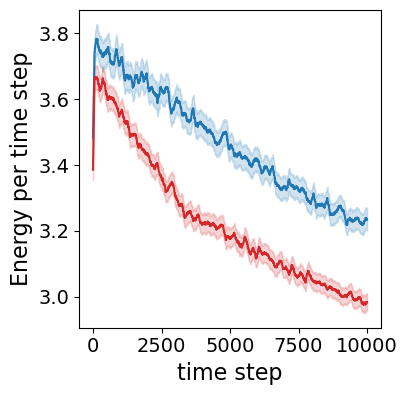

Total CTR/FR energy ratio: 1.073


In [92]:
ctr_curve = aggregate_energy_curve(
    energy_tensors,
    ampar=CTR_PAIR[0],
    rin=CTR_PAIR[1],
    sigma_temp=PLOT_TEMP,
    sigma_eta=PLOT_ETA,
    sigma_theta=PLOT_SIGMA_THETA,
    recurrent_width=PLOT_RECURRENT_WIDTH,
    active_fraction=CTR_ACTIVE_FRACTION,
    metric=PLOT_METRIC,
)

fr_curve = aggregate_energy_curve(
    energy_tensors,
    ampar=FR_PAIR[0],
    rin=FR_PAIR[1],
    sigma_temp=PLOT_TEMP,
    sigma_eta=PLOT_ETA,
    sigma_theta=PLOT_SIGMA_THETA,
    recurrent_width=PLOT_RECURRENT_WIDTH,
    active_fraction=FR_ACTIVE_FRACTION,
    metric=PLOT_METRIC,
)

if ctr_curve["generation"].shape[0] != fr_curve["generation"].shape[0]:
    min_len = min(ctr_curve["generation"].shape[0], fr_curve["generation"].shape[0])
    print(
        f"[energy] Warning: generation length mismatch CTR={ctr_curve['generation'].shape[0]} "
        f"vs FR={fr_curve['generation'].shape[0]}; trimming to {min_len}."
    )
    for curve in (ctr_curve, fr_curve):
        curve["generation"] = curve["generation"][:min_len]
        curve["mean"] = curve["mean"][:min_len]
        curve["sem"] = curve["sem"][:min_len]

gen = ctr_curve["generation"]
ENERGY_SMOOTH_WINDOW = 101  # generations; set to 1 to show the unsmoothed per-generation curve


def centered_rolling_mean(values, window):
    values = np.asarray(values, dtype=float)
    window = int(max(1, min(window, values.size)))
    if window == 1:
        return values
    kernel = np.ones(window, dtype=float) / window
    pad_left = window // 2
    pad_right = window - 1 - pad_left
    padded = np.pad(values, (pad_left, pad_right), mode="edge")
    return np.convolve(padded, kernel, mode="valid")


ctr_mean = centered_rolling_mean(ctr_curve["mean"], ENERGY_SMOOTH_WINDOW)
ctr_sem = centered_rolling_mean(ctr_curve["sem"], ENERGY_SMOOTH_WINDOW)
fr_mean = centered_rolling_mean(fr_curve["mean"], ENERGY_SMOOTH_WINDOW)
fr_sem = centered_rolling_mean(fr_curve["sem"], ENERGY_SMOOTH_WINDOW)

plt.figure(figsize=(4,4))
plt.plot(gen, ctr_mean, color="tab:blue", label=f"CTR rolling mean (n={ctr_curve['n_runs']})")
plt.fill_between(
    gen,
    ctr_mean - ctr_sem,
    ctr_mean + ctr_sem,
    color="tab:blue",
    alpha=0.2,
)

plt.plot(gen, fr_mean, color="tab:red", label=f"FR rolling mean (n={fr_curve['n_runs']})")
plt.fill_between(
    gen,
    fr_mean - fr_sem,
    fr_mean + fr_sem,
    color="tab:red",
    alpha=0.2,
)

plt.xlabel("time step", fontsize=16)
plt.ylabel("Energy per time step", fontsize=16)
# plt.title(
#     "Rolling Per-Generation Synaptic Energy Use (FR vs CTR)\n"
#     f"metric={PLOT_METRIC}, T={PLOT_TEMP}, eta={PLOT_ETA}, sigma_theta={PLOT_SIGMA_THETA}, "
#     f"w_rec={PLOT_RECURRENT_WIDTH}, afrac CTR/FR={CTR_ACTIVE_FRACTION}/{FR_ACTIVE_FRACTION}, "
#     f"window={ENERGY_SMOOTH_WINDOW} gens"
# )
# plt.legend(frameon=False)
# plt.grid(True, linestyle="--", alpha=0.35)
plt.tight_layout()
plt.tick_params(axis='both', which='major', labelsize=14)
plt.show()

ctr_total = np.nansum(ctr_curve["mean"])
fr_total = np.nansum(fr_curve["mean"])
if fr_total > 0:
    print(f"Total CTR/FR energy ratio: {ctr_total / fr_total:.4g}")
else:
    print("Total CTR/FR energy ratio: undefined because FR total is zero.")

